In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Load

In [61]:
df=pd.read_csv(r"C:\Users\arya wardhana\Documents\Rakamin\Mini Project\Predict Customer Personality to Boost Marketing Campaign by Using Machine Learning\tahap02\marketing_campaign_data.csv")
df

,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,5524,1957,S1,Lajang,58138000.0,0,0,04-09-2012,58,...,7,0,0,0,0,0,0,3,11,1
1,1,2174,1954,S1,Lajang,46344000.0,1,1,08-03-2014,38,...,5,0,0,0,0,0,0,3,11,0
2,2,4141,1965,S1,Bertunangan,71613000.0,0,0,21-08-2013,26,...,4,0,0,0,0,0,0,3,11,0
3,3,6182,1984,S1,Bertunangan,26646000.0,1,0,10-02-2014,26,...,6,0,0,0,0,0,0,3,11,0
4,4,5324,1981,S3,Menikah,58293000.0,1,0,19-01-2014,94,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,2235,10870,1967,S1,Menikah,61223000.0,0,1,13-06-2013,46,...,5,0,0,0,0,0,0,3,11,0
2236,2236,4001,1946,S3,Bertunangan,64014000.0,2,1,10-06-2014,56,...,7,0,0,0,1,0,0,3,11,0
2237,2237,7270,1981,S1,Cerai,56981000.0,0,0,25-01-2014,91,...,6,0,1,0,0,0,0,3,11,0
2238,2238,8235,1956,S2,Bertunangan,69245000.0,0,1,24-01-2014,8,...,3,0,0,0,0,0,0,3,11,0


# Overall Conversion Rate

In [62]:
conversion_rate = df["Response"].mean()

print(f"Conversion Rate: {conversion_rate:.2%}")

Conversion Rate: 14.91%


# Pembentukan Grup Umur

In [63]:
current_year = 2020

df["Age"] = current_year - df["Year_Birth"]

In [64]:
df = df[df['Age'] <= 90]

In [65]:
df["Age"].describe()

count    2237.000000
mean       51.098346
std        11.701917
min        24.000000
25%        43.000000
50%        50.000000
75%        61.000000
max        80.000000
Name: Age, dtype: float64

In [66]:
# grouping Age

bins = [0, 18, 25, 35, 45, np.inf]
labels = ["young", "teen", "young_adult", "adult", "senior"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False
)

In [67]:
df[["Year_Birth","Age","Age_Group"]].head()

,Year_Birth,Age,Age_Group
0,1957,63,senior
1,1954,66,senior
2,1965,55,senior
3,1984,36,adult
4,1981,39,adult


In [68]:
df["Age_Group"].value_counts()

Age_Group
senior         1542
adult           506
young_adult     187
teen              2
young             0
Name: count, dtype: int64

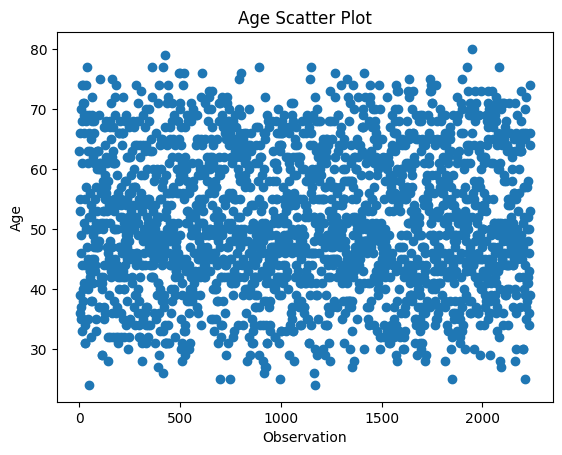

In [69]:
plt.scatter(df.index, df["Age"])

plt.title("Age Scatter Plot")
plt.xlabel("Observation")
plt.ylabel("Age")
plt.show()

# Plot Relationship Between Conversion Rate and User Type

In [70]:
conversion_by_age = (
    df.groupby("Age_Group")["Response"]
      .mean()
      .reset_index()
)

print(conversion_by_age)

     Age_Group  Response
0         teen  0.500000
1  young_adult  0.165775
2        adult  0.152174
3       senior  0.145914


C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_23364\1894312892.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


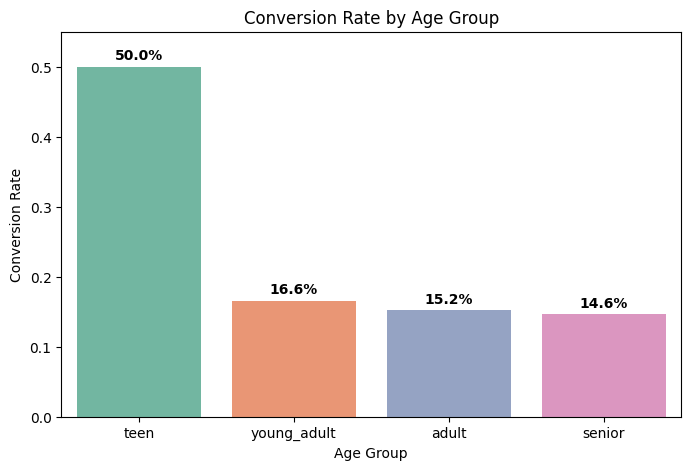

In [71]:
plt.figure(figsize=(8,5))

order = (
    conversion_by_age
    .sort_values("Response", ascending=False)["Age_Group"]
)

ax = sns.barplot(
    data=conversion_by_age,
    x="Age_Group",
    y="Response",
    order=order,
    palette="Set2"
)

#pemberian label pada ujung bar
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f"{height:.1%}",  # untuk format persentase
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),    
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Conversion Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate")
plt.ylim(0, conversion_by_age["Response"].max() + 0.05)

plt.show()

In [72]:
##p < 0.05 → Adanya pengaruh umur pada respon kampanye.
##p ≥ 0.05 → Tidak ada pengaruh.

from scipy.stats import chi2_contingency

table = pd.crosstab(df["Age_Group"], df["Response"])

chi2, p, dof, expected = chi2_contingency(table)

print(f"P-value: {p:.2f}")


P-value: 0.47


# Cleaning Data

## Quick check

In [73]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 2237 entries, 0 to 2239
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Unnamed: 0           2237 non-null   int64   
 1   ID                   2237 non-null   int64   
 2   Year_Birth           2237 non-null   int64   
 3   Education            2237 non-null   str     
 4   Marital_Status       2237 non-null   str     
 5   Income               2213 non-null   float64 
 6   Kidhome              2237 non-null   int64   
 7   Teenhome             2237 non-null   int64   
 8   Dt_Customer          2237 non-null   str     
 9   Recency              2237 non-null   int64   
 10  MntCoke              2237 non-null   int64   
 11  MntFruits            2237 non-null   int64   
 12  MntMeatProducts      2237 non-null   int64   
 13  MntFishProducts      2237 non-null   int64   
 14  MntSweetProducts     2237 non-null   int64   
 15  MntGoldProds         2237 non-null   

In [74]:
print(df.head())

   Unnamed: 0    ID  Year_Birth Education Marital_Status      Income  Kidhome  \
0           0  5524        1957        S1         Lajang  58138000.0        0   
1           1  2174        1954        S1         Lajang  46344000.0        1   
2           2  4141        1965        S1    Bertunangan  71613000.0        0   
3           3  6182        1984        S1    Bertunangan  26646000.0        1   
4           4  5324        1981        S3        Menikah  58293000.0        1   

   Teenhome Dt_Customer  Recency  ...  AcceptedCmp4  AcceptedCmp5  \
0         0  04-09-2012       58  ...             0             0   
1         1  08-03-2014       38  ...             0             0   
2         0  21-08-2013       26  ...             0             0   
3         0  10-02-2014       26  ...             0             0   
4         0  19-01-2014       94  ...             0             0   

   AcceptedCmp1  AcceptedCmp2  Complain  Z_CostContact  Z_Revenue  Response  \
0             0    

## Missing Check

In [75]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing = missing[missing["Missing Values"] > 0]
print(missing)

        Missing Values  Percentage
Income              24    1.072865


### Filling missing

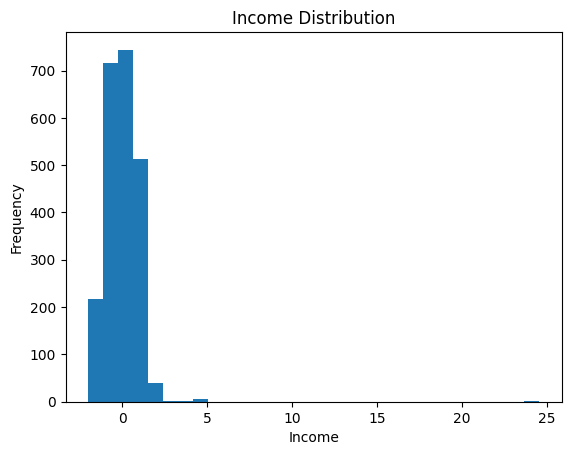

In [85]:
plt.hist(df["Income"], bins=30)
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Income Distribution")
plt.show()

In [76]:
df["Income"] = df["Income"].fillna(df["Income"].median())

missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing = missing[missing["Missing Values"] > 0]
print(missing)

Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


## Duplicate Check

In [77]:
duplicates = df.duplicated().sum()
print(f"Duplicated rows: {duplicates}")

Duplicated rows: 0


# One-Hot Encoding

In [78]:
df = pd.get_dummies(
    df,
    columns=["Education", "Marital_Status", "Age_Group"],
    drop_first=True
)

In [79]:
df.sample(10)

,Unnamed: 0,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntCoke,MntFruits,...,Education_SMA,Marital_Status_Cerai,Marital_Status_Duda,Marital_Status_Janda,Marital_Status_Lajang,Marital_Status_Menikah,Age_Group_teen,Age_Group_young_adult,Age_Group_adult,Age_Group_senior
671,671,10379,1962,59247000.0,0,2,08-11-2013,87,327000,9000,...,False,False,False,False,True,False,False,False,False,True
2024,2024,4837,1965,71322000.0,0,1,16-02-2013,57,753000,43000,...,False,False,False,False,False,True,False,False,False,True
1583,1583,5223,1966,45903000.0,0,1,23-04-2014,80,33000,8000,...,False,False,False,False,False,False,False,False,False,True
1290,1290,4808,1956,15759000.0,0,0,05-09-2013,12,1000,2000,...,False,False,False,False,False,True,False,False,False,True
449,449,1142,1953,55707000.0,0,1,22-12-2013,91,208000,7000,...,False,False,False,False,False,True,False,False,False,True
1509,1509,10128,1958,53977000.0,0,1,08-06-2013,21,620000,16000,...,False,False,False,False,False,False,False,False,False,True
882,882,8916,1975,36627000.0,2,0,23-07-2013,78,9000,1000,...,False,True,False,False,False,False,False,False,False,True
32,32,5710,1970,40548000.0,0,1,10-10-2012,31,110000,0,...,False,False,False,False,False,False,False,False,False,True
1255,1255,6653,1970,55158000.0,1,1,30-07-2012,72,293000,0,...,False,False,False,False,False,True,False,False,False,True
1661,1661,1404,1968,34916000.0,2,0,15-05-2013,89,51000,23000,...,False,False,False,False,False,False,False,False,False,True


# Standarisasi

In [81]:
numeric_cols = [
    "Income",
    "Kidhome",
    "Teenhome",
    "Recency",
    "MntCoke",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Complain",
    "Response",
    "Age"
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [82]:
df.sample(10)

,Unnamed: 0,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntCoke,MntFruits,...,Education_SMA,Marital_Status_Cerai,Marital_Status_Duda,Marital_Status_Janda,Marital_Status_Lajang,Marital_Status_Menikah,Age_Group_teen,Age_Group_young_adult,Age_Group_adult,Age_Group_senior
123,123,7386,1976,-0.848135,1.032151,-0.930227,22-04-2013,1.170842,-0.852886,-0.661606,...,False,True,False,False,False,False,False,False,True,False
280,280,4669,1981,-1.108223,1.032151,-0.930227,11-02-2013,-0.107242,-0.891519,-0.183102,...,True,False,False,False,False,True,False,False,True,False
1504,1504,3584,1955,-0.102259,-0.825388,-0.930227,20-08-2012,-0.487212,2.606261,-0.006811,...,False,False,False,False,True,False,False,False,False,True
1485,1485,9988,1976,0.724975,-0.825388,0.906417,03-03-2013,1.205384,0.739985,-0.031996,...,False,False,False,False,True,False,False,False,True,False
1546,1546,6365,1987,-0.872178,-0.825388,-0.930227,02-09-2013,-1.523496,-0.873689,-0.359393,...,False,False,False,False,False,True,False,True,False,False
1197,1197,6606,1969,0.713472,1.032151,-0.930227,31-03-2013,-1.316239,1.961385,0.194664,...,False,False,False,False,False,True,False,False,False,True
237,237,9449,1958,1.099690,-0.825388,0.906417,04-10-2013,-0.590841,0.329880,-0.535684,...,False,False,False,False,True,False,False,False,False,True
567,567,891,1951,-0.915793,1.032151,0.906417,07-09-2013,0.376357,-0.885576,-0.661606,...,False,False,False,False,False,False,False,False,False,True
791,791,10446,1957,1.189794,-0.825388,-0.930227,07-11-2012,0.307272,-0.356600,-0.082364,...,False,False,False,False,False,True,False,False,False,True
1083,1083,9523,1982,-0.469226,1.032151,-0.930227,17-08-2013,1.585355,-0.888548,-0.661606,...,False,False,False,False,False,False,False,False,True,False


# COBA_COBA